## XGBoost Model

In this section, we implement XGBoost as an improvement over the Decision Tree baseline model. XGBoost is an ensemble learning method that builds multiple trees sequentially to improve performance and reduce overfitting.

The model is evaluated using accuracy, precision, recall, F1 score, and confusion matrix to compare its performance against the baseline model.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


In [4]:
# Convert -1,1 → 0,1 for XGBoost
y = y.replace({-1: 0, 1: 1})

In [5]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# Tune XGBoost on train set using CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20,
    cv=skf,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)
xgb = search.best_estimator_

cv_results = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)
print("Best Params:", search.best_params_)
print(f"CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")

# Train the best model and predict on hold-out test set
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

/Users/khushinanda/Library/Python/3.9/lib/python/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [8]:
# Evaluate the tuned XGBoost model
print("XGBoost (Tuned with CV) Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results:

Accuracy: 0.9547008547008548
Precision: 0.9523809523809523
Recall: 0.9540636042402827
F1 Score: 0.9532215357458076

Confusion Matrix:
[[577  27]
 [ 26 540]]


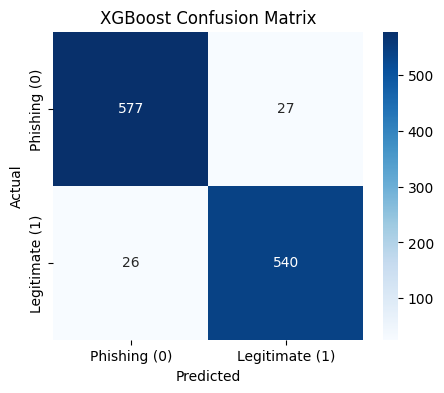

In [9]:
# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Phishing (0)", "Legitimate (1)"],
            yticklabels=["Phishing (0)", "Legitimate (1)"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

### XGBoost Results Analysis

The XGBoost model demonstrates excellent performance and significantly improves upon the Decision Tree baseline.

The model achieved an accuracy of approximately 95.47%, which is higher than the Decision Tree model. The precision (~0.952) indicates that the model is highly accurate when predicting phishing websites, while the recall (~0.954) shows that it successfully identifies a large proportion of phishing cases. The F1 score (~0.953) reflects a strong balance between precision and recall.

From the confusion matrix:
- 577 phishing websites were correctly classified.
- 540 legitimate websites were correctly classified.
- 27 phishing websites were misclassified as legitimate.
- 26 legitimate websites were misclassified as phishing.

Overall, the XGBoost model produces fewer misclassifications compared to the Decision Tree, demonstrating improved predictive performance and better generalization. This highlights the effectiveness of ensemble learning methods for phishing detection.

In [10]:
# Check for overfitting
y_train_pred_xgb = xgb.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))

Train Accuracy: 0.9713614020089762
Test Accuracy: 0.9547008547008548


### Overfitting Analysis

The XGBoost model achieves a training accuracy of approximately 97.14% and a test accuracy of approximately 95.47%, resulting in a very small performance gap.

This indicates that the model does not significantly overfit the training data and generalizes well to unseen data. Compared to the Decision Tree model, which showed a larger gap between training and test accuracy, XGBoost demonstrates improved generalization.

Overall, the ensemble learning approach used by XGBoost helps reduce overfitting while maintaining high predictive performance.

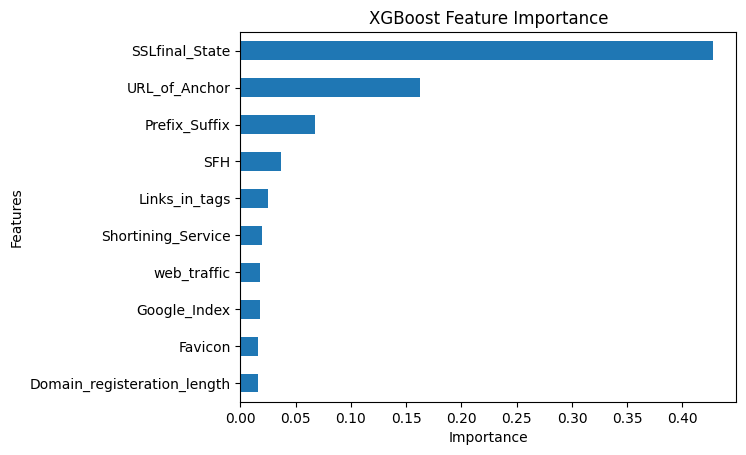

In [15]:
# Top 10 Feature Importance
feat_importance_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
feat_importance_xgb = feat_importance_xgb.sort_values(ascending=False)

feat_importance_xgb.head(10).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # highest importance at top
plt.show()

### Top 10 Important Features (XGBoost)

The following features were identified as the most important based on the XGBoost model:

1. SSLfinal_State  
2. URL_of_Anchor  
3. Prefix_Suffix  
4. SFH  
5. Links_in_tags  
6. Shortening_Service  
7. web_traffic  
8. Google_Index  
9. Favicon  
10. Domain_registeration_length  

## XGBoost Summary and Model Comparison

The XGBoost model demonstrates superior performance compared to the Decision Tree baseline for phishing website detection. The model achieved an accuracy of approximately 95.47%, along with high precision, recall, and F1 score, indicating strong and balanced classification performance.

Compared to the Decision Tree model (accuracy ~92.5%), XGBoost provides a clear improvement across all evaluation metrics. It also produces fewer misclassifications, as shown in the confusion matrix, highlighting its ability to more accurately distinguish between phishing and legitimate websites.

In terms of generalization, XGBoost shows minimal overfitting, with a small difference between training accuracy (~97.14%) and test accuracy (~95.47%). In contrast, the Decision Tree exhibited moderate overfitting due to its high complexity, with a training accuracy of approximately 99.1% and a test accuracy of approximately 92.5%, indicating a larger gap between training and test performance.

The improved performance of XGBoost can be attributed to its ensemble learning approach, which combines multiple decision trees to reduce variance and improve predictive accuracy. Additionally, feature importance analysis confirms that XGBoost effectively captures key indicators of phishing, including website security, URL structure, and domain credibility.

Overall, XGBoost provides a clear improvement over the Decision Tree baseline and serves as a strong model for phishing detection. 